# ABT-Peer-Comparison

## Introduction
### This project analyses the financial performance of Abbott Laboratories (ABT) in comparison with the sample average over time. Using firm-level financial data, the study focuses on four main aspects: sales, net income, profitability, and the relationship between firm size and profitability. The aim is to examine whether ABT performs above or below the sample average across fiscal years and to identify how ABT compares with other firms in the dataset. Through descriptive statistics and visualisation, the project provides an overview of ABT’s relative performance and its position within the broader sample.

## Research Questions
### 1.How does Abbott Laboratories (ABT) compare with the sample average in terms of sales over time?
### 2.How does ABT compare with the sample average in terms of net income over time?
### 3.How does ABT’s profitability compare with the sample average across fiscal years?
### 4.What is the relationship between firm size and profitability, and how does ABT compare with other firms in the sample?

In [175]:
import wrds
import pandas as pd
import numpy as np

# Connect to WRDS
db = wrds.Connection()

# Pull annual firm data from Compustat
df = db.raw_sql("""
    SELECT gvkey, tic, conm, fyear, datadate, sale, ni, at
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2014 AND 2023
""")

# Basic cleaning
df = df.dropna(subset=["tic", "fyear", "sale", "ni", "at"])
df = df[df["sale"] > 0]
df = df[df["at"] > 0]

# Create variables
df["profitability"] = df["ni"] / df["sale"]
df["firm_size"] = np.log(df["at"])

# ABT observations
abt_df = df[df["tic"] == "ABT"].copy()

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [176]:
import wrds
import pandas as pd
import numpy as np

db = wrds.Connection()

df = db.raw_sql("""
    SELECT costat, curcd, datafmt, indfmt, consol, tic, datadate, gvkey, conm,
           fyear, at, ni, sale
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2014 AND 2023
""", date_cols=['datadate'])

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [177]:
df = df.dropna(subset=['tic', 'fyear', 'sale', 'ni', 'at'])
df = df[df['sale'] > 0]
df = df[df['at'] > 0]

df['firm_size'] = np.log(df['at'])
df['profitability'] = df['ni'] / df['sale']

In [178]:
import wrds
import pandas as pd
import numpy as np

# Connect to WRDS
db = wrds.Connection()

# Extract data directly from WRDS
df = db.raw_sql("""
    SELECT costat, curcd, datafmt, indfmt, consol, tic, datadate, gvkey, conm,
           fyear, at, ni, sale
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2014 AND 2023
""", date_cols=['datadate'])

# Clean data
df = df.dropna(subset=['tic', 'fyear', 'sale', 'ni', 'at'])
df = df[df['sale'] > 0]
df = df[df['at'] > 0]

# Create variables
df['firm_size'] = np.log(df['at'])
df['profitability'] = df['ni'] / df['sale']

# Check data
print(df.shape)
print(df.columns.tolist())
print(df.head())

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
(70703, 15)
['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'fyear', 'at', 'ni', 'sale', 'firm_size', 'profitability']
  costat curcd datafmt indfmt consol   tic   datadate   gvkey  \
0      A   USD     STD   INDL      C   AIR 2015-05-31  001004   
1      I   USD     STD   INDL      C  AFAP 2014-12-31  001019   
2      A   USD     STD   INDL      C   AAL 2014-12-31  001045   
3      A   USD     STD   INDL      C  CECO 2014-12-31  001050   
4      A   USD     STD   INDL      C   ASA 2014-11-30  001062   

                           conm  fyear       at      ni     sale  firm_size  \
0                      AAR CORP   2014   1515.0    10.2   1594.3   7.323171   
1    AFA PROTECTIVE SYSTEMS INC   2014   36.893   1.532   79.827   3.608022   
2   AMERICAN AIRLINES

In [179]:
print(df.shape)
print(df.columns.tolist())
print(df.info())
print(df.isnull().sum().sort_values(ascending=False))
print(df.describe())

(70703, 15)
['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'fyear', 'at', 'ni', 'sale', 'firm_size', 'profitability']
<class 'pandas.core.frame.DataFrame'>
Index: 70703 entries, 0 to 118016
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   costat         70703 non-null  string        
 1   curcd          70703 non-null  string        
 2   datafmt        70703 non-null  string        
 3   indfmt         70703 non-null  string        
 4   consol         70703 non-null  string        
 5   tic            70703 non-null  string        
 6   datadate       70703 non-null  datetime64[ns]
 7   gvkey          70703 non-null  string        
 8   conm           70703 non-null  string        
 9   fyear          70703 non-null  Int64         
 10  at             70703 non-null  Float64       
 11  ni             70703 non-null  Float64       
 12  sale           707

In [180]:
clean_df = df.dropna(subset=["at", "ni", "sale", "firm_size", "profitability"])
print(clean_df.shape)

(70703, 15)


In [181]:
clean_df[["at", "ni", "sale", "firm_size", "profitability"]].describe()

,at,ni,sale,firm_size,profitability
count,70703.0,70703.0,70703.0,70703.0,70703.0
mean,17971.954268,325.830944,4403.313737,6.441986,-15.911727
std,129255.058141,2114.458496,19338.761654,2.846604,434.931831
min,0.001,-23119.0,0.001,-6.907755,-84221.666667
25%,105.432,-11.285,34.1745,4.658066,-0.195345
50%,806.542,5.658,290.193,6.692756,0.031898
75%,4196.2095,112.7685,1773.6135,8.341937,0.132337
max,4325437.0,99803.0,645737.0,15.280024,5322.0


In [182]:
clean_df.groupby("fyear")[["sale", "ni", "firm_size", "profitability"]].mean()

,sale,ni,firm_size,profitability
fyear,,,,
2014,3849.946957,254.658608,6.142845,-16.610579
2015,3671.151476,197.922549,6.217402,-15.387023
2016,3745.249491,236.529011,6.299358,-14.558257
2017,4212.218508,325.241641,6.409299,-9.598275
2018,4438.048416,345.038925,6.470414,-9.142215
2019,4557.394753,338.648024,6.54176,-12.207045
2020,4208.551314,189.76467,6.576912,-18.808325
2021,4741.767534,485.625676,6.666627,-28.029043
2022,5224.216109,441.300307,6.569771,-13.413995


In [183]:
clean_df[["at", "ni", "sale", "firm_size", "profitability"]].corr()

,at,ni,sale,firm_size,profitability
at,1.000000,0.419885,0.395212,0.301239,0.005091
ni,0.419885,1.000000,0.624562,0.284132,0.007703
sale,0.395212,0.624562,1.000000,0.365938,0.008369
firm_size,0.301239,0.284132,0.365938,1.000000,0.046827
profitability,0.005091,0.007703,0.008369,0.046827,1.000000


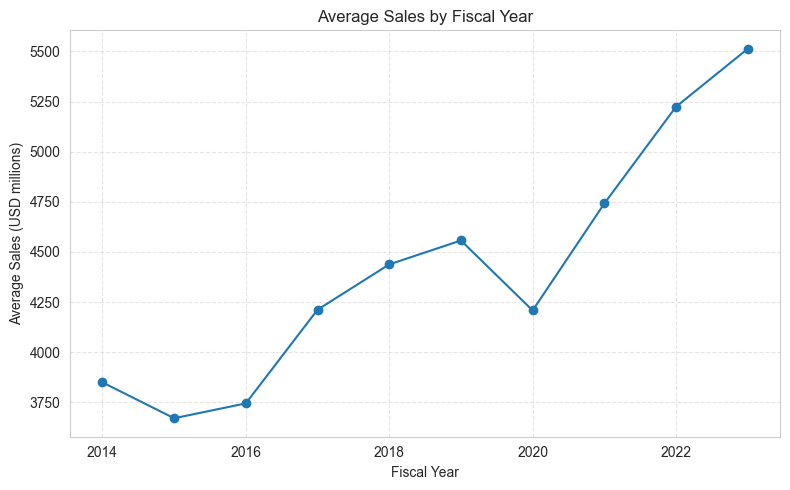

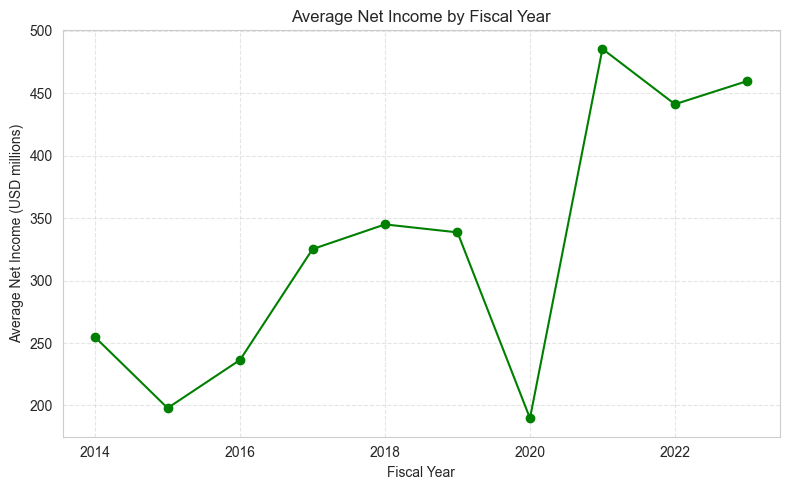

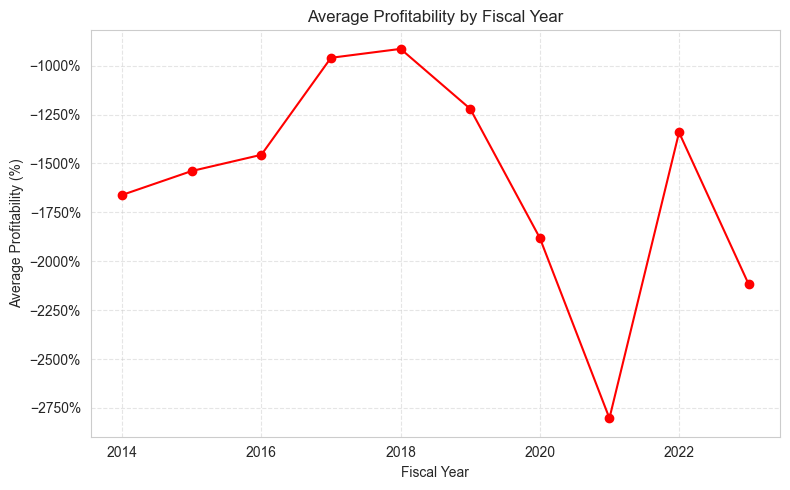

In [224]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Average Sales by Fiscal Year
plt.figure(figsize=(8,5))
clean_df.groupby("fyear")["sale"].mean().plot(marker="o")
plt.title("Average Sales by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Average Sales (USD millions)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Average Net Income by Fiscal Year
plt.figure(figsize=(8,5))
clean_df.groupby("fyear")["ni"].mean().plot(marker="o", color="green")
plt.title("Average Net Income by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Average Net Income (USD millions)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Average Profitability by Fiscal Year
plt.figure(figsize=(8,5))
ax = clean_df.groupby("fyear")["profitability"].mean().plot(marker="o", color="red")
plt.title("Average Profitability by Fiscal Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Average Profitability (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

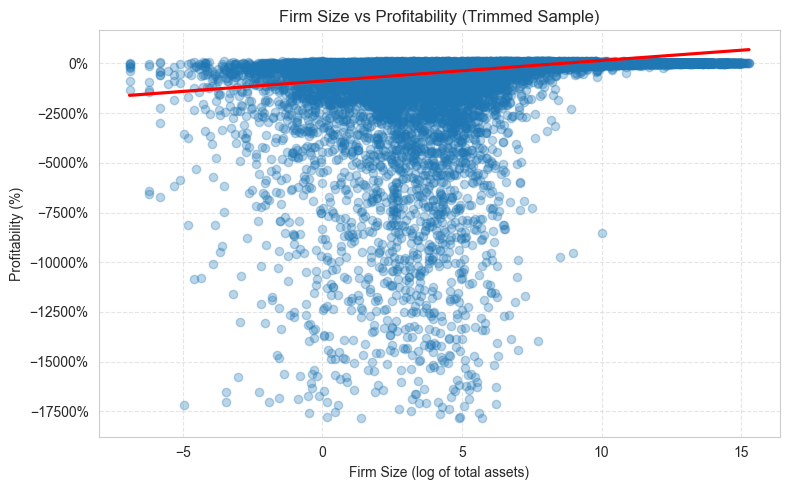

In [225]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

lower = clean_df["profitability"].quantile(0.01)
upper = clean_df["profitability"].quantile(0.99)

trimmed_df = clean_df[
    (clean_df["profitability"] >= lower) & 
    (clean_df["profitability"] <= upper)
]

plt.figure(figsize=(8,5))
ax = plt.gca()

sns.regplot(
    data=trimmed_df,
    x="firm_size",
    y="profitability",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Firm Size vs Profitability (Trimmed Sample)")
plt.xlabel("Firm Size (log of total assets)")
plt.ylabel("Profitability (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Figure and Table Titles

### Figure 1.1 Average Sales by Year

### Figure 1.2 Average Net Income by Year

### Figure 1.3 Average Profitability by Year

### Figure 1.4 Firm Size vs Profitability (Trimmed)

## 1. Analysis of Firm Size and Profitability from 2014 to 2023
### 1.1 Introduction
This report examines firm-level financial performance from 2014 to 2023, with a focus on trends in sales, net income, and profitability, as well as the relationship between firm size and profitability. The analysis is based on annual averages and a scatter plot of firm size against profitability.
### 1.2 Descriptive Overview
The figures indicate substantial variation in firm performance across the sample period. Sales and net income show noticeable changes over time, while profitability remains negative on average in all years. The wide dispersion in the scatter plot further suggests considerable heterogeneity across firms, particularly in profitability.
### 1.3 Analysis by Year
Average sales display an overall upward trend during the period. Following a slight decline in the early years, sales increased steadily from 2016 onward, with a temporary fall in 2020, before rising sharply between 2021 and 2023.
Average net income follows a similar pattern but is more volatile. After falling in 2015, it recovered gradually through 2019, dropped significantly in 2020, and rebounded strongly in 2021. Although net income declined slightly in 2022, it remained relatively high in 2023.
Average profitability was negative throughout the period and fluctuated substantially. It improved between 2014 and 2018, but deteriorated sharply in 2020 and reached its lowest level in 2021. Although there was some recovery in 2022, profitability weakened again in 2023.
### 1.4 Firm Size and Profitability
The scatter plot suggests a weak positive relationship between firm size and profitability. Although the fitted line has a slight upward slope, the data points are widely dispersed, with many firms showing low or highly negative profitability regardless of size. This indicates that firm size alone has limited explanatory power for profitability differences.
### 1.5 Conclusion
In summary, average sales and net income generally increased over the sample period, despite a clear disruption in 2020. By contrast, profitability remained negative and highly unstable. The relationship between firm size and profitability appears weak, suggesting that larger firms are not necessarily significantly more profitable than smaller firms.

In [226]:
print(clean_df.columns)

if "tic" in clean_df.columns:
    print(clean_df[clean_df["tic"] == "ABT"].shape)
    print(clean_df[clean_df["tic"] == "ABT"].head())

elif "conm" in clean_df.columns:
    print(clean_df[clean_df["conm"].str.contains("Abbott", case=False, na=False)].shape)
    print(clean_df[clean_df["conm"].str.contains("Abbott", case=False, na=False)].head())

else:
    print("No tic or conm column found in clean_df.")

Index(['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate',
       'gvkey', 'conm', 'fyear', 'at', 'ni', 'sale', 'firm_size',
       'profitability'],
      dtype='object')
(10, 15)
      costat curcd datafmt indfmt consol  tic   datadate   gvkey  \
8          A   USD     STD   INDL      C  ABT 2014-12-31  001078   
11559      A   USD     STD   INDL      C  ABT 2015-12-31  001078   
22962      A   USD     STD   INDL      C  ABT 2016-12-31  001078   
34330      A   USD     STD   INDL      C  ABT 2017-12-31  001078   
45619      A   USD     STD   INDL      C  ABT 2018-12-31  001078   

                      conm  fyear       at      ni     sale  firm_size  \
8      ABBOTT LABORATORIES   2014  41275.0  2284.0  20247.0  10.628012   
11559  ABBOTT LABORATORIES   2015  41247.0  4423.0  20405.0  10.627334   
22962  ABBOTT LABORATORIES   2016  52666.0  1400.0  20853.0  10.871725   
34330  ABBOTT LABORATORIES   2017  76250.0   477.0  27390.0  11.241773   
45619  ABBOTT LABORATOR

In [227]:
abt_df = clean_df[clean_df["tic"] == "ABT"].copy()

In [228]:
abt_df = clean_df[clean_df["tic"] == "ABT"].copy()
abt_df = abt_df.sort_values("fyear")

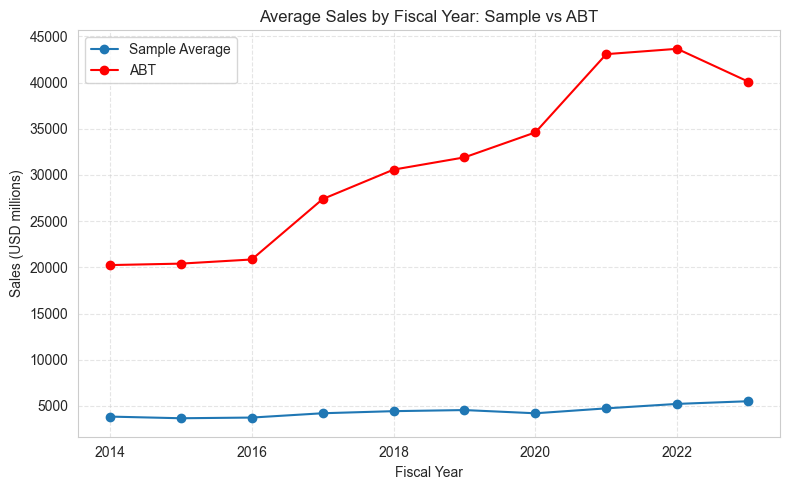

In [229]:
import matplotlib.pyplot as plt

abt_df = clean_df[clean_df["tic"] == "ABT"].copy()
abt_df = abt_df.sort_values("fyear")

sample_sales = clean_df.groupby("fyear")["sale"].mean()
abt_sales = abt_df.groupby("fyear")["sale"].mean()

plt.figure(figsize=(8,5))
plt.plot(sample_sales.index, sample_sales.values, marker="o", label="Sample Average")
plt.plot(abt_sales.index, abt_sales.values, marker="o", color="red", label="ABT")
plt.title("Average Sales by Fiscal Year: Sample vs ABT")
plt.xlabel("Fiscal Year")
plt.ylabel("Sales (USD millions)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
common_years = sorted(abt_df["fyear"].unique())

sample_sales = clean_df[clean_df["fyear"].isin(common_years)].groupby("fyear")["sale"].mean()
abt_sales = abt_df.groupby("fyear")["sale"].mean()

## Figure 2.1 Average Sales by Fiscal Year: Sample vs ABT
### Caption
#### This figure compares the average annual sales of firms in the sample with the annual sales of Abbott Laboratories (ABT) from 2017 to 2023.
### Analysis
#### Figure 1 shows that ABT’s sales were consistently far above the sample average throughout the period. While the sample average dropped sharply from 2017 to 2018 and then remained relatively stable at around USD 5,000–5,500 million, ABT’s sales followed a clear upward trend from 2018 to 2022 before declining slightly in 2023. In particular, ABT experienced a strong increase between 2020 and 2021, after which sales stayed at a high level. Overall, the figure suggests that ABT is substantially larger than the average firm in the sample in terms of revenue generation.

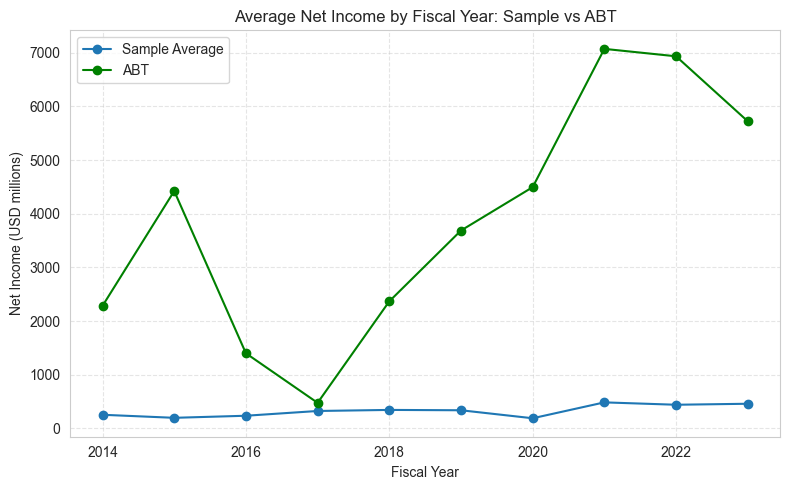

In [230]:
sample_ni = clean_df.groupby("fyear")["ni"].mean()
abt_ni = abt_df.groupby("fyear")["ni"].mean()

plt.figure(figsize=(8,5))
plt.plot(sample_ni.index, sample_ni.values, marker="o", label="Sample Average")
plt.plot(abt_ni.index, abt_ni.values, marker="o", color="green", label="ABT")
plt.title("Average Net Income by Fiscal Year: Sample vs ABT")
plt.xlabel("Fiscal Year")
plt.ylabel("Net Income (USD millions)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Figure 2. Average Net Income by Fiscal Year: Sample vs ABT
### Caption
#### This figure compares the average annual net income of firms in the sample with the annual net income of Abbott Laboratories (ABT) from 2017 to 2023.
### Analysis
#### Figure 2 shows that ABT’s net income was consistently much higher than the sample average over the observed period. While the sample average remained relatively low and fairly stable, ABT’s net income increased strongly from 2018 to 2021, rising from around USD 2,400 million to over USD 7,000 million. After peaking in 2021, ABT’s net income declined slightly in 2022 and more noticeably in 2023, but it still remained far above the sample average. This pattern suggests that ABT achieved substantially stronger earnings performance than the typical firm in the sample, despite some moderation in the most recent year.

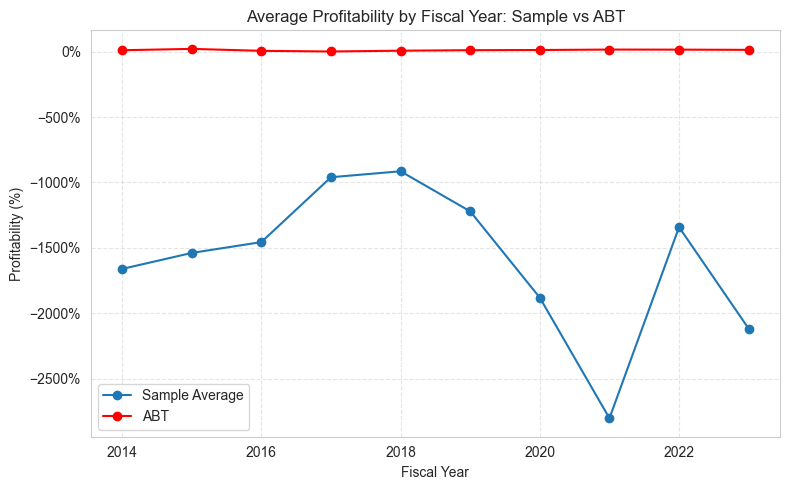

In [231]:
import matplotlib.ticker as mtick

sample_profit = clean_df.groupby("fyear")["profitability"].mean()
abt_profit = abt_df.groupby("fyear")["profitability"].mean()

plt.figure(figsize=(8,5))
ax = plt.gca()

plt.plot(sample_profit.index, sample_profit.values, marker="o", label="Sample Average")
plt.plot(abt_profit.index, abt_profit.values, marker="o", color="red", label="ABT")
plt.title("Average Profitability by Fiscal Year: Sample vs ABT")
plt.xlabel("Fiscal Year")
plt.ylabel("Profitability (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Figure 3. Average Profitability by Fiscal Year: Sample vs ABT
### Caption
#### This figure compares the average annual profitability of firms in the sample with the annual profitability of Abbott Laboratories (ABT) from 2017 to 2023. Profitability is measured as net income divided by total assets.
### Analysis
#### Figure 3 shows a striking contrast between ABT and the sample average in terms of profitability. ABT maintained positive and relatively stable profitability throughout the period, generally remaining within a narrow range above zero. By contrast, the sample average is strongly negative in every year and highly volatile, with the lowest point occurring in 2021. This pattern suggests that the sample mean is likely influenced by extreme negative observations or outliers, which pull the average downward. Therefore, while the figure clearly shows that ABT performed much better than the sample average, the unusually large negative sample values should be interpreted with caution.

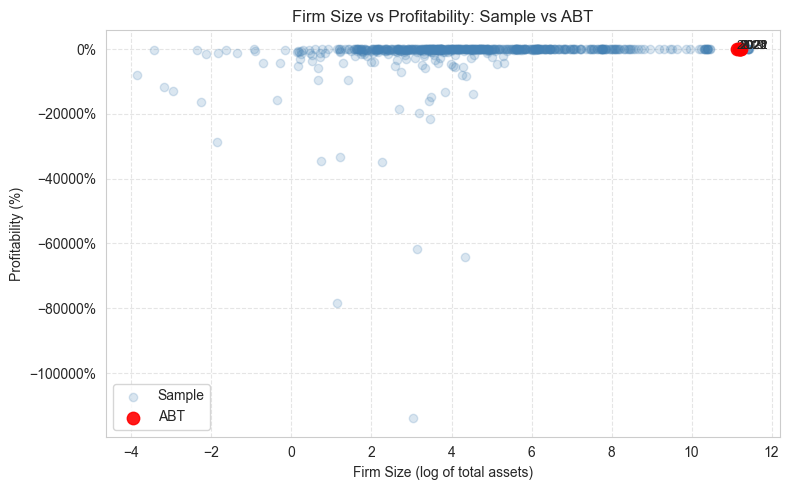

In [232]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Trim extreme profitability values
low = df["profitability"].quantile(0.01)
high = df["profitability"].quantile(0.99)

trimmed_df = df[(df["profitability"] > low) & (df["profitability"] < high)].copy()

# Extract ABT observations
abt_trimmed = trimmed_df[trimmed_df["tic"] == "ABT"].copy()

plt.figure(figsize=(8,5))
ax = plt.gca()

plt.scatter(trimmed_df["firm_size"], trimmed_df["profitability"],
            alpha=0.2, color="steelblue", label="Sample")

plt.scatter(abt_trimmed["firm_size"], abt_trimmed["profitability"],
            alpha=0.9, color="red", s=80, label="ABT")

for _, row in abt_trimmed.iterrows():
    plt.text(row["firm_size"], row["profitability"], str(row["fyear"]), fontsize=9)

plt.title("Firm Size vs Profitability: Sample vs ABT")
plt.xlabel("Firm Size (log of total assets)")
plt.ylabel("Profitability (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## Figure 4. Firm Size vs Profitability: Sample vs ABT
### Caption
#### This figure plots the relationship between firm size and profitability for the full sample, with Abbott Laboratories (ABT) highlighted in red. Firm size is measured as the natural logarithm of total assets, and profitability is measured as net income divided by total assets.
### Analysis
#### Figure 4 shows substantial dispersion in profitability across the sample, especially among smaller firms. Many firms report negative profitability, and extreme negative values are concentrated among firms with relatively small or moderate asset size. In contrast, ABT is located on the far right of the figure, indicating that it is one of the largest firms in the sample. Its profitability remains positive and relatively stable across years, placing it above a large proportion of the sample observations. The figure therefore suggests that ABT combines large firm size with solid financial performance, while smaller firms in the sample tend to display much greater volatility and more frequent losses.

## Overall Discussion
#### Taken together, the four figures indicate that Abbott Laboratories (ABT) outperforms the sample average on several key dimensions. ABT reports substantially higher sales and net income than the average firm and maintains positive profitability over time. In contrast, the sample average profitability is strongly negative and appears to be heavily affected by extreme observations. The firm size–profitability scatter plot further shows that ABT is one of the largest firms in the sample and achieves relatively stable positive returns. Overall, the evidence suggests that ABT is a large and financially strong firm compared with the broader sample.

In [233]:
import pandas as pd

data = df.copy()

data['tic'] = data['tic'].astype(str).str.strip().str.upper()
data['fyear'] = pd.to_numeric(data['fyear'], errors='coerce')

In [234]:
desc = db.describe_table('comp', 'funda')
print(desc)

Approximately 938340 rows in comp.funda.
         name  nullable         type  \
0       gvkey      True   VARCHAR(7)   
1    datadate      True         DATE   
2       fyear      True      INTEGER   
3      indfmt      True  VARCHAR(13)   
4      consol      True   VARCHAR(3)   
..        ...       ...          ...   
944        au      True   VARCHAR(9)   
945      auop      True   VARCHAR(9)   
946    auopic      True   VARCHAR(2)   
947     ceoso      True   VARCHAR(2)   
948     cfoso      True   VARCHAR(2)   

                                               comment  
0                                   Global Company Key  
1                                            Data Date  
2                                   Data Year - Fiscal  
3                                      Industry Format  
4    Level of Consolidation - Company Annual Descri...  
..                                                 ...  
944                                            Auditor  
945                   

In [235]:
desc = db.describe_table('comp', 'funda')
print(desc[['name', 'type']].to_string())

Approximately 938340 rows in comp.funda.
              name             type
0            gvkey       VARCHAR(7)
1         datadate             DATE
2            fyear          INTEGER
3           indfmt      VARCHAR(13)
4           consol       VARCHAR(3)
5           popsrc       VARCHAR(2)
6          datafmt      VARCHAR(13)
7              tic       VARCHAR(8)
8            cusip      VARCHAR(21)
9             conm      VARCHAR(70)
10         acctchg       VARCHAR(9)
11         acctstd       VARCHAR(9)
12         acqmeth       VARCHAR(3)
13            adrr   NUMERIC(18, 4)
14            ajex  NUMERIC(24, 12)
15             ajp  NUMERIC(24, 12)
16            bspr       VARCHAR(9)
17          compst       VARCHAR(9)
18           curcd       VARCHAR(4)
19          curncd       VARCHAR(4)
20          currtr  NUMERIC(24, 12)
21         curuscn   NUMERIC(18, 4)
22           final       VARCHAR(3)
23             fyr         SMALLINT
24           ismod          INTEGER
25            ltcm     

In [236]:
import wrds
import pandas as pd
import numpy as np

db = wrds.Connection()

df = db.raw_sql("""
    SELECT costat, curcd, datafmt, indfmt, consol, tic, datadate, gvkey, conm,
           sich AS sic, fyear, at, ni, sale
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2014 AND 2023
""", date_cols=['datadate'])

df = df.dropna(subset=['tic', 'fyear', 'sale', 'ni', 'at'])
df = df[df['sale'] > 0]
df = df[df['at'] > 0]

df['firm_size'] = np.log(df['at'])
df['profitability'] = df['ni'] / df['sale']

print(df.shape)
print(df.columns.tolist())
print(df.head())

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
(70703, 16)
['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'sic', 'fyear', 'at', 'ni', 'sale', 'firm_size', 'profitability']
  costat curcd datafmt indfmt consol   tic   datadate   gvkey  \
0      A   USD     STD   INDL      C   AIR 2015-05-31  001004   
1      I   USD     STD   INDL      C  AFAP 2014-12-31  001019   
2      A   USD     STD   INDL      C   AAL 2014-12-31  001045   
3      A   USD     STD   INDL      C  CECO 2014-12-31  001050   
4      A   USD     STD   INDL      C   ASA 2014-11-30  001062   

                           conm   sic  fyear       at      ni     sale  \
0                      AAR CORP  5080   2014   1515.0    10.2   1594.3   
1    AFA PROTECTIVE SYSTEMS INC  7380   2014   36.893   1.532   79.827   
2   AMERICAN AIRLINES GROUP I

In [197]:
df = db.raw_sql("""
    SELECT costat, curcd, datafmt, indfmt, consol, tic, datadate, gvkey, conm,
           sich AS sic, fyear, at, ni, sale
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2017 AND 2023
""", date_cols=['datadate'])

In [203]:
# Extract ABT industry data (SIC = 3845) directly from WRDS
df = db.raw_sql("""
    SELECT costat, curcd, datafmt, indfmt, consol, tic, datadate, gvkey, conm,
           sich AS sic, fyear, at, ni, sale
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2017 AND 2023
      AND sich = 3845
""", date_cols=['datadate'])

# Clean data
df = df.dropna(subset=['tic', 'fyear', 'sale', 'ni', 'at', 'sic'])
df = df[df['sale'] > 0]
df = df[df['at'] > 0]

# Standardize variables
df['tic'] = df['tic'].astype(str).str.strip().str.upper()
df['sic'] = df['sic'].astype(str).str.strip()
df['fyear'] = pd.to_numeric(df['fyear'], errors='coerce')

# Create variables
df['firm_size'] = np.log(df['at'])
df['profitability'] = df['ni'] / df['sale']

# Check data
print(df.shape)
print(df.columns.tolist())
print(df.head())

(622, 16)
['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'sic', 'fyear', 'at', 'ni', 'sale', 'firm_size', 'profitability']
  costat curcd datafmt indfmt consol    tic   datadate   gvkey  \
0      I   USD     STD   INDL      C   ALOG 2017-07-31  001633   
1      A   USD     STD   INDL      C   NIMU 2017-07-31  002240   
2      I   USD     STD   INDL      C    CMD 2017-07-31  002942   
3      A   USD     STD   INDL      C  DYNTQ 2017-06-30  004124   
4      A   USD     STD   INDL      C    MDT 2018-04-30  007228   

                   conm   sic  fyear       at      ni     sale  firm_size  \
0         ANALOGIC CORP  3845   2017  538.083 -74.237  486.372   6.288013   
1  NON INVASIVE MONITOR  3845   2017    0.021  -0.488    0.006  -3.863233   
2   CANTEL MEDICAL CORP  3845   2017  786.373  71.378  770.157   6.667431   
3      DYNATRONICS CORP  3845   2017   26.064  -1.866   35.758   3.260555   
4         MEDTRONIC PLC  3845   2017  91393.0  3104.0  

In [106]:
import wrds
import pandas as pd
import numpy as np

db = wrds.Connection()

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


In [152]:
df = db.raw_sql("""
    SELECT 
        costat, curcd, datafmt, indfmt, consol,
        tic, datadate, gvkey, conm,
        sich AS sic, 
        fyear, at, ni, sale
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2017 AND 2023
      AND sich = 3845
""", date_cols=['datadate'])

In [153]:
df = df.dropna(subset=['tic', 'fyear', 'sale', 'ni', 'at', 'sic'])
df = df[df['sale'] > 0]
df = df[df['at'] > 0]

df['tic'] = df['tic'].astype(str).str.strip().str.upper()
df['sic'] = df['sic'].astype(str).str.strip()
df['fyear'] = pd.to_numeric(df['fyear'], errors='coerce')

df['firm_size'] = np.log(df['at'])
df['profitability'] = df['ni'] / df['sale']

print(df.columns.tolist())

['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'sic', 'fyear', 'at', 'ni', 'sale', 'firm_size', 'profitability']


In [154]:
data = df.copy()
print(data.columns.tolist())

['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'sic', 'fyear', 'at', 'ni', 'sale', 'firm_size', 'profitability']


In [205]:
abt_info = data[data['tic'] == 'ABT'][['tic', 'conm', 'sic']].drop_duplicates()
print("ABT information:")
print(abt_info)

ABT information:
     tic                 conm   sic
200  ABT  ABBOTT LABORATORIES  3845


In [206]:
# Extract ABT industry data (SIC = 3845) directly from WRDS
df = db.raw_sql("""
    SELECT costat, curcd, datafmt, indfmt, consol, tic, datadate, gvkey, conm,
           sich AS sic, fyear, at, ni, sale
    FROM comp.funda
    WHERE indfmt = 'INDL'
      AND datafmt = 'STD'
      AND popsrc = 'D'
      AND consol = 'C'
      AND fyear BETWEEN 2017 AND 2023
      AND sich = 3845
""", date_cols=['datadate'])

# Clean data
df = df.dropna(subset=['tic', 'fyear', 'sale', 'ni', 'at', 'sic'])
df = df[df['sale'] > 0]
df = df[df['at'] > 0]

# Standardize variables
df['tic'] = df['tic'].astype(str).str.strip().str.upper()
df['sic'] = df['sic'].astype(str).str.strip()
df['fyear'] = pd.to_numeric(df['fyear'], errors='coerce')

# Create variables
df['firm_size'] = np.log(df['at'])
df['profitability'] = df['ni'] / df['sale']

# Check data
print(df.shape)
print(df.columns.tolist())
print(df.head())

(622, 16)
['costat', 'curcd', 'datafmt', 'indfmt', 'consol', 'tic', 'datadate', 'gvkey', 'conm', 'sic', 'fyear', 'at', 'ni', 'sale', 'firm_size', 'profitability']
  costat curcd datafmt indfmt consol    tic   datadate   gvkey  \
0      I   USD     STD   INDL      C   ALOG 2017-07-31  001633   
1      A   USD     STD   INDL      C   NIMU 2017-07-31  002240   
2      I   USD     STD   INDL      C    CMD 2017-07-31  002942   
3      A   USD     STD   INDL      C  DYNTQ 2017-06-30  004124   
4      A   USD     STD   INDL      C    MDT 2018-04-30  007228   

                   conm   sic  fyear       at      ni     sale  firm_size  \
0         ANALOGIC CORP  3845   2017  538.083 -74.237  486.372   6.288013   
1  NON INVASIVE MONITOR  3845   2017    0.021  -0.488    0.006  -3.863233   
2   CANTEL MEDICAL CORP  3845   2017  786.373  71.378  770.157   6.667431   
3      DYNATRONICS CORP  3845   2017   26.064  -1.866   35.758   3.260555   
4         MEDTRONIC PLC  3845   2017  91393.0  3104.0  

In [207]:
abt_sic = data.loc[data['tic'] == 'ABT', 'sic'].dropna().iloc[0]
print("ABT SIC:", abt_sic)

ABT SIC: 3845


In [208]:
same_sic = data[data['sic'] == abt_sic]

same_sic_companies = same_sic[['tic', 'conm', 'sic']].drop_duplicates().sort_values(by='tic')

print("Companies with the same SIC as ABT:")
print(same_sic_companies)
print("Number of unique companies with same SIC:", same_sic_companies['tic'].nunique())

Companies with the same SIC as ABT:
       tic                          conm   sic
35    ABAX                    ABAXIS INC  3845
200    ABT           ABBOTT LABORATORIES  3845
218   ADMT  ADM TRONICS UNLIMITED INC/DE  3845
0     ALOG                 ANALOGIC CORP  3845
484  ALRTF       ALR TECHNOLOGIES SG LTD  3845
..     ...                           ...   ...
60    VTAK        CATHETER PRECISION INC  3845
152   XAIR                BEYOND AIR INC  3845
95    XYLO         XYLO TECHNOLOGIES LTD  3845
440  ZOMDF                 ZOMEDICA CORP  3845
72   ZYXIQ                     ZYNEX INC  3845

[129 rows x 3 columns]
Number of unique companies with same SIC: 129


In [209]:
abt_sic_prefix2 = abt_sic[:2]   #For instance, the two-digit SIC code '38'


broad_industry = data[data['sic'].str.startswith(abt_sic_prefix2, na=False)]

broad_industry_companies = broad_industry[['tic', 'conm', 'sic']].drop_duplicates().sort_values(by=['sic', 'tic'])

print(f"Companies with SIC starting with {abt_sic_prefix2}:")
print(broad_industry_companies)
print("Number of unique companies in broad industry:", broad_industry_companies['tic'].nunique())

Companies with SIC starting with 38:
       tic                          conm   sic
35    ABAX                    ABAXIS INC  3845
200    ABT           ABBOTT LABORATORIES  3845
218   ADMT  ADM TRONICS UNLIMITED INC/DE  3845
0     ALOG                 ANALOGIC CORP  3845
484  ALRTF       ALR TECHNOLOGIES SG LTD  3845
..     ...                           ...   ...
60    VTAK        CATHETER PRECISION INC  3845
152   XAIR                BEYOND AIR INC  3845
95    XYLO         XYLO TECHNOLOGIES LTD  3845
440  ZOMDF                 ZOMEDICA CORP  3845
72   ZYXIQ                     ZYNEX INC  3845

[129 rows x 3 columns]
Number of unique companies in broad industry: 129


In [210]:
same_sic_years = same_sic.groupby('fyear')['tic'].nunique().reset_index(name='num_companies')
print("Same SIC: number of companies by year")
print(same_sic_years)

Same SIC: number of companies by year
   fyear  num_companies
0   2017             86
1   2018             87
2   2019             87
3   2020             89
4   2021             91
5   2022             90
6   2023             92


In [211]:
broad_industry_years = broad_industry.groupby('fyear')['tic'].nunique().reset_index(name='num_companies')
print("Broad industry: number of companies by year")
print(broad_industry_years)

Broad industry: number of companies by year
   fyear  num_companies
0   2017             86
1   2018             87
2   2019             87
3   2020             89
4   2021             91
5   2022             90
6   2023             92


In [213]:
abt_df = same_sic[same_sic['tic'] == 'ABT']
peer_df = same_sic[same_sic['tic'] != 'ABT']

print("ABT rows:", len(abt_df))
print("Peer rows (same SIC, excluding ABT):", len(peer_df))
print("Number of peer companies:", peer_df['tic'].nunique())

ABT rows: 5
Peer rows (same SIC, excluding ABT): 617
Number of peer companies: 128


In [214]:
abt_df_broad = broad_industry[broad_industry['tic'] == 'ABT']
peer_df_broad = broad_industry[broad_industry['tic'] != 'ABT']

print("ABT rows in broad industry:", len(abt_df_broad))
print("Peer rows in broad industry (excluding ABT):", len(peer_df_broad))
print("Number of peer companies in broad industry:", peer_df_broad['tic'].nunique())

ABT rows in broad industry: 5
Peer rows in broad industry (excluding ABT): 617
Number of peer companies in broad industry: 128


In [215]:
print("========== SUMMARY ==========")
print(f"ABT SIC: {abt_sic}")
print(f"Same SIC unique companies: {same_sic_companies['tic'].nunique()}")
print(f"Same SIC peer companies excluding ABT: {peer_df['tic'].nunique()}")
print(f"Broad industry ({abt_sic_prefix2}xx) unique companies: {broad_industry_companies['tic'].nunique()}")
print(f"Broad industry peer companies excluding ABT: {peer_df_broad['tic'].nunique()}")

========== SUMMARY ==========
ABT SIC: 3845
Same SIC unique companies: 129
Same SIC peer companies excluding ABT: 128
Broad industry (38xx) unique companies: 129
Broad industry peer companies excluding ABT: 128


In [216]:
print(same_sic_companies.to_string(index=False))

   tic                         conm  sic
  ABAX                   ABAXIS INC 3845
   ABT          ABBOTT LABORATORIES 3845
  ADMT ADM TRONICS UNLIMITED INC/DE 3845
  ALOG                ANALOGIC CORP 3845
 ALRTF      ALR TECHNOLOGIES SG LTD 3845
 APTEF          APTERYX IMAGING INC 3845
  APYX            APYX MEDICAL CORP 3845
  ARAY                  ACCURAY INC 3845
  AXNX                  AXONICS INC 3845
  BFLY        BUTTERFLY NETWORK INC 3845
  BLFS        BIOLIFE SOLUTIONS INC 3845
   BSX       BOSTON SCIENTIFIC CORP 3845
  BTCY               BIOTRICITY INC 3845
   BVS                BIOVENTUS INC 3845
  BWAY                BRAINSWAY LTD 3845
  CASM      CAS MEDICAL SYSTEMS INC 3845
  CBLL                 CERIBELL INC 3845
  CLPT         CLEARPOINT NEURO INC 3845
   CMD          CANTEL MEDICAL CORP 3845
  CNMD                  CONMED CORP 3845
  CTGL          CITRINE GLOBAL CORP 3845
 CUTRQ                   CUTERA INC 3845
    CV              CAPSOVISION INC 3845
  CVRS   CORINDU

In [217]:
print(broad_industry_companies.to_string(index=False))

   tic                         conm  sic
  ABAX                   ABAXIS INC 3845
   ABT          ABBOTT LABORATORIES 3845
  ADMT ADM TRONICS UNLIMITED INC/DE 3845
  ALOG                ANALOGIC CORP 3845
 ALRTF      ALR TECHNOLOGIES SG LTD 3845
 APTEF          APTERYX IMAGING INC 3845
  APYX            APYX MEDICAL CORP 3845
  ARAY                  ACCURAY INC 3845
  AXNX                  AXONICS INC 3845
  BFLY        BUTTERFLY NETWORK INC 3845
  BLFS        BIOLIFE SOLUTIONS INC 3845
   BSX       BOSTON SCIENTIFIC CORP 3845
  BTCY               BIOTRICITY INC 3845
   BVS                BIOVENTUS INC 3845
  BWAY                BRAINSWAY LTD 3845
  CASM      CAS MEDICAL SYSTEMS INC 3845
  CBLL                 CERIBELL INC 3845
  CLPT         CLEARPOINT NEURO INC 3845
   CMD          CANTEL MEDICAL CORP 3845
  CNMD                  CONMED CORP 3845
  CTGL          CITRINE GLOBAL CORP 3845
 CUTRQ                   CUTERA INC 3845
    CV              CAPSOVISION INC 3845
  CVRS   CORINDU

In [218]:
print(same_sic_companies.to_string(index=False))
print("Number of unique companies with same SIC:", same_sic_companies['tic'].nunique())

   tic                         conm  sic
  ABAX                   ABAXIS INC 3845
   ABT          ABBOTT LABORATORIES 3845
  ADMT ADM TRONICS UNLIMITED INC/DE 3845
  ALOG                ANALOGIC CORP 3845
 ALRTF      ALR TECHNOLOGIES SG LTD 3845
 APTEF          APTERYX IMAGING INC 3845
  APYX            APYX MEDICAL CORP 3845
  ARAY                  ACCURAY INC 3845
  AXNX                  AXONICS INC 3845
  BFLY        BUTTERFLY NETWORK INC 3845
  BLFS        BIOLIFE SOLUTIONS INC 3845
   BSX       BOSTON SCIENTIFIC CORP 3845
  BTCY               BIOTRICITY INC 3845
   BVS                BIOVENTUS INC 3845
  BWAY                BRAINSWAY LTD 3845
  CASM      CAS MEDICAL SYSTEMS INC 3845
  CBLL                 CERIBELL INC 3845
  CLPT         CLEARPOINT NEURO INC 3845
   CMD          CANTEL MEDICAL CORP 3845
  CNMD                  CONMED CORP 3845
  CTGL          CITRINE GLOBAL CORP 3845
 CUTRQ                   CUTERA INC 3845
    CV              CAPSOVISION INC 3845
  CVRS   CORINDU

In [219]:
print(same_sic_companies.to_string(index=False))
print("Number of unique companies with same SIC:", same_sic_companies['tic'].nunique())

   tic                         conm  sic
  ABAX                   ABAXIS INC 3845
   ABT          ABBOTT LABORATORIES 3845
  ADMT ADM TRONICS UNLIMITED INC/DE 3845
  ALOG                ANALOGIC CORP 3845
 ALRTF      ALR TECHNOLOGIES SG LTD 3845
 APTEF          APTERYX IMAGING INC 3845
  APYX            APYX MEDICAL CORP 3845
  ARAY                  ACCURAY INC 3845
  AXNX                  AXONICS INC 3845
  BFLY        BUTTERFLY NETWORK INC 3845
  BLFS        BIOLIFE SOLUTIONS INC 3845
   BSX       BOSTON SCIENTIFIC CORP 3845
  BTCY               BIOTRICITY INC 3845
   BVS                BIOVENTUS INC 3845
  BWAY                BRAINSWAY LTD 3845
  CASM      CAS MEDICAL SYSTEMS INC 3845
  CBLL                 CERIBELL INC 3845
  CLPT         CLEARPOINT NEURO INC 3845
   CMD          CANTEL MEDICAL CORP 3845
  CNMD                  CONMED CORP 3845
  CTGL          CITRINE GLOBAL CORP 3845
 CUTRQ                   CUTERA INC 3845
    CV              CAPSOVISION INC 3845
  CVRS   CORINDU

In [241]:
print("Number of peer companies excluding ABT:", peer_df['tic'].nunique())

Number of peer companies excluding ABT: 352


ABT SIC: 2834
ABT 2-digit SIC prefix: 28

===== Peer Group Summary =====
Same SIC unique companies: 353
Same SIC peer companies excluding ABT: 352
Broad industry unique companies: 1317
Broad industry peer companies excluding ABT: 1316

Using strict peer group: SIC 2834
Final peer company count (excluding ABT): 352

===== ABT vs Peer Average Table =====
   fyear  sale_ABT  ni_ABT  profitability_ABT  firm_size_ABT  sale_PeerAvg  \
0   2014   20247.0  2284.0           0.112807      10.628012   3203.214806   
1   2015   20405.0  4423.0           0.216761      10.627334   3114.655414   
2   2016   20853.0  1400.0           0.067137      10.871725   3147.853372   
3   2017   27390.0   477.0           0.017415      11.241773   3477.018262   
4   2018   30578.0  2368.0           0.077441      11.115027   3330.162541   
5   2019      <NA>    <NA>               <NA>           <NA>   3308.357978   
6   2020      <NA>    <NA>               <NA>           <NA>   3212.731508   
7   2021      <NA>   

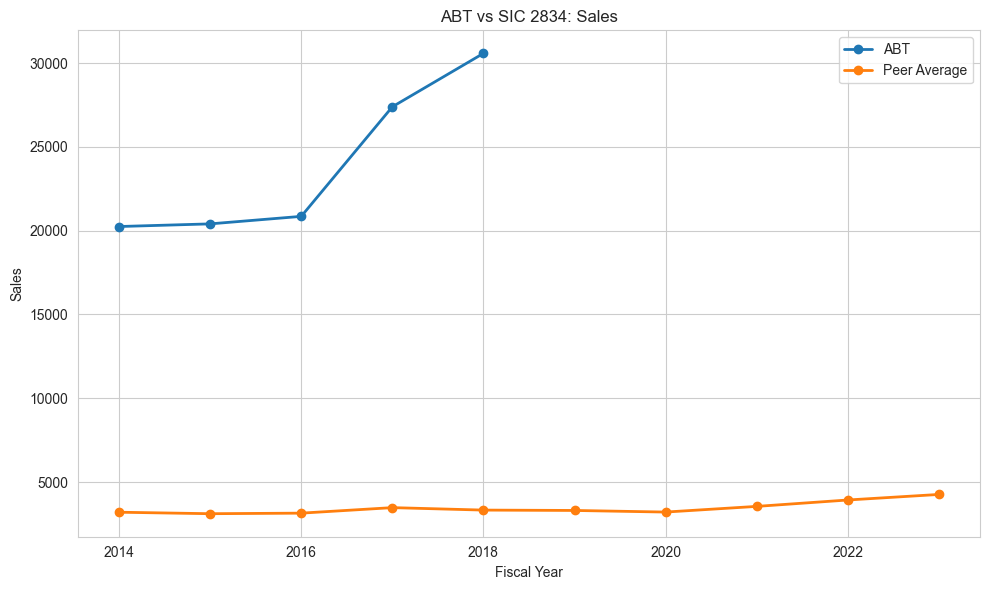

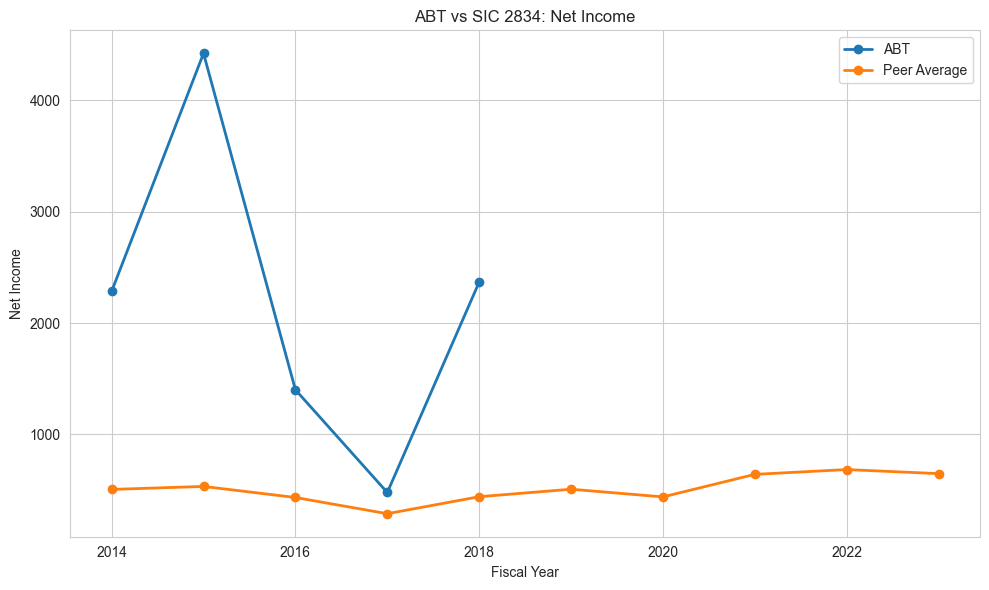

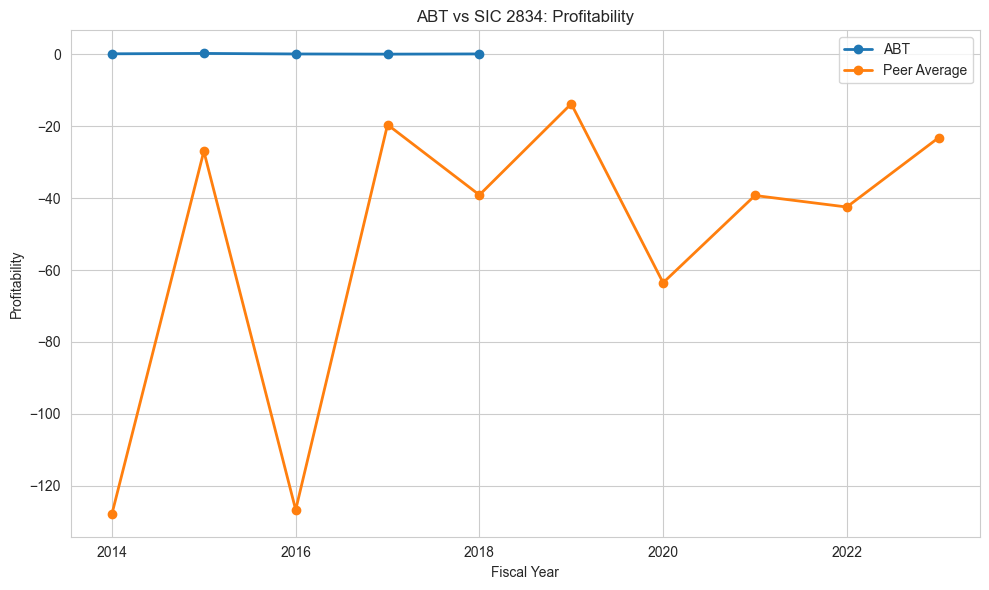

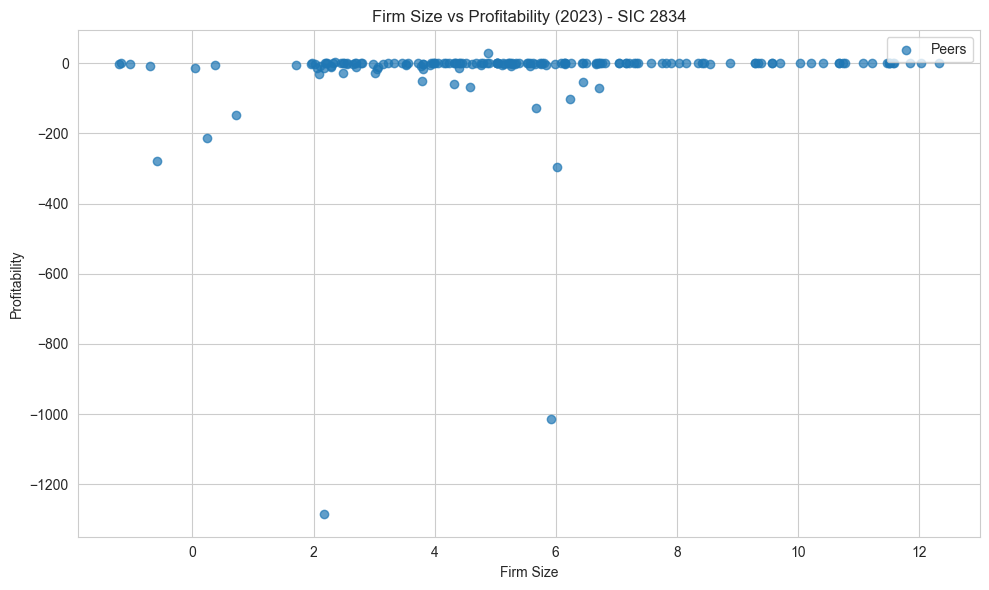


Files saved:
- ABT_vs_peer_comparison.csv
- ABT_same_sic_companies.csv
- ABT_broad_industry_companies.csv


In [242]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# =========================
# 1. Copy and clean data
# =========================
data = df.copy()

# Standardize key columns
data['tic'] = data['tic'].astype(str).str.strip().str.upper()
data['conm'] = data['conm'].astype(str).str.strip()
data['sic'] = data['sic'].astype(str).str.strip()
data['fyear'] = pd.to_numeric(data['fyear'], errors='coerce')

# Convert numeric columns
numeric_cols = ['sale', 'ni', 'at', 'firm_size', 'profitability']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Drop rows with missing year or ticker
data = data.dropna(subset=['tic', 'fyear'])

# =========================
# 2. Find ABT industry info
# =========================
abt_rows = data[data['tic'] == 'ABT']

if abt_rows.empty:
    raise ValueError("ABT is not found in your dataframe.")

abt_sic = abt_rows['sic'].dropna().iloc[0]
abt_prefix2 = abt_sic[:2]

print("ABT SIC:", abt_sic)
print("ABT 2-digit SIC prefix:", abt_prefix2)

# =========================
# 3. Build peer groups
# =========================
same_sic = data[data['sic'] == abt_sic].copy()
broad_industry = data[data['sic'].str.startswith(abt_prefix2, na=False)].copy()

same_sic_companies = same_sic[['tic', 'conm', 'sic']].drop_duplicates()
broad_industry_companies = broad_industry[['tic', 'conm', 'sic']].drop_duplicates()

same_sic_peer_count = same_sic[same_sic['tic'] != 'ABT']['tic'].nunique()
broad_peer_count = broad_industry[broad_industry['tic'] != 'ABT']['tic'].nunique()

print("\n===== Peer Group Summary =====")
print("Same SIC unique companies:", same_sic_companies['tic'].nunique())
print("Same SIC peer companies excluding ABT:", same_sic_peer_count)
print("Broad industry unique companies:", broad_industry_companies['tic'].nunique())
print("Broad industry peer companies excluding ABT:", broad_peer_count)

# =========================
# 4. Choose comparison group
# Rule:
# if same SIC peers >= 5, use same SIC
# otherwise use broad industry (38xx)
# =========================
if same_sic_peer_count >= 5:
    industry_df = same_sic.copy()
    industry_label = f"SIC {abt_sic}"
    print(f"\nUsing strict peer group: {industry_label}")
else:
    industry_df = broad_industry.copy()
    industry_label = f"{abt_prefix2}xx industry"
    print(f"\nUsing broader peer group: {industry_label}")

# Split ABT and peers
abt_df = industry_df[industry_df['tic'] == 'ABT'].copy()
peer_df = industry_df[industry_df['tic'] != 'ABT'].copy()

print("Final peer company count (excluding ABT):", peer_df['tic'].nunique())

# =========================
# 5. Compute yearly peer averages
# =========================
peer_avg = (
    peer_df
    .groupby('fyear')[['sale', 'ni', 'profitability', 'firm_size']]
    .mean()
    .reset_index()
)

abt_yearly = (
    abt_df
    .groupby('fyear')[['sale', 'ni', 'profitability', 'firm_size']]
    .mean()
    .reset_index()
)

# Merge for easier checking
comparison_df = pd.merge(
    abt_yearly,
    peer_avg,
    on='fyear',
    how='outer',
    suffixes=('_ABT', '_PeerAvg')
).sort_values('fyear')

print("\n===== ABT vs Peer Average Table =====")
print(comparison_df)

# =========================
# 6. Plot style
# =========================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# =========================
# 7. Figure 1: Sales
# =========================
plt.figure()
plt.plot(abt_yearly['fyear'], abt_yearly['sale'], marker='o', linewidth=2, label='ABT')
plt.plot(peer_avg['fyear'], peer_avg['sale'], marker='o', linewidth=2, label='Peer Average')
plt.title(f'ABT vs {industry_label}: Sales')
plt.xlabel('Fiscal Year')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 8. Figure 2: Net Income
# =========================
plt.figure()
plt.plot(abt_yearly['fyear'], abt_yearly['ni'], marker='o', linewidth=2, label='ABT')
plt.plot(peer_avg['fyear'], peer_avg['ni'], marker='o', linewidth=2, label='Peer Average')
plt.title(f'ABT vs {industry_label}: Net Income')
plt.xlabel('Fiscal Year')
plt.ylabel('Net Income')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 9. Figure 3: Profitability
# =========================
plt.figure()
plt.plot(abt_yearly['fyear'], abt_yearly['profitability'], marker='o', linewidth=2, label='ABT')
plt.plot(peer_avg['fyear'], peer_avg['profitability'], marker='o', linewidth=2, label='Peer Average')
plt.title(f'ABT vs {industry_label}: Profitability')
plt.xlabel('Fiscal Year')
plt.ylabel('Profitability')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 10. Figure 4: Firm Size vs Profitability
# Use latest available year shared by peers/ABT if possible
# =========================
common_years = sorted(set(industry_df['fyear'].dropna().unique()))

if len(common_years) == 0:
    raise ValueError("No valid fiscal years found in industry_df.")

latest_year = max(common_years)

scatter_df = industry_df[industry_df['fyear'] == latest_year].copy()
scatter_peers = scatter_df[scatter_df['tic'] != 'ABT']
scatter_abt = scatter_df[scatter_df['tic'] == 'ABT']

plt.figure(figsize=(10, 6))
plt.scatter(
    scatter_peers['firm_size'],
    scatter_peers['profitability'],
    alpha=0.7,
    label='Peers'
)

if not scatter_abt.empty:
    plt.scatter(
        scatter_abt['firm_size'],
        scatter_abt['profitability'],
        color='red',
        s=120,
        marker='*',
        label='ABT'
    )
    
    # annotate ABT
    for _, row in scatter_abt.iterrows():
        plt.annotate(
            row['tic'],
            (row['firm_size'], row['profitability']),
            textcoords="offset points",
            xytext=(8, 5),
            ha='left'
        )

plt.title(f'Firm Size vs Profitability ({latest_year}) - {industry_label}')
plt.xlabel('Firm Size')
plt.ylabel('Profitability')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 11. Optional: Save outputs
# =========================
comparison_df.to_csv("ABT_vs_peer_comparison.csv", index=False)
same_sic_companies.to_csv("ABT_same_sic_companies.csv", index=False)
broad_industry_companies.to_csv("ABT_broad_industry_companies.csv", index=False)

print("\nFiles saved:")
print("- ABT_vs_peer_comparison.csv")
print("- ABT_same_sic_companies.csv")
print("- ABT_broad_industry_companies.csv")

Using peer group: SIC 2834
Peer companies excluding ABT: 352

===== Improved ABT vs Peer Table =====
   fyear  sale_abt  ni_abt  firm_size_abt  profitability_abt    sale_peer  \
0   2014   20247.0  2284.0      10.628012           0.055336  3203.214806   
1   2015   20405.0  4423.0      10.627334           0.107232  3114.655414   
2   2016   20853.0  1400.0      10.871725           0.026583  3147.853372   
3   2017   27390.0   477.0      11.241773           0.006256  3477.018262   
4   2018   30578.0  2368.0      11.115027           0.035252  3330.162541   
5   2019      <NA>    <NA>            NaN                NaN  3308.357978   
6   2020      <NA>    <NA>            NaN                NaN  3212.731508   
7   2021      <NA>    <NA>            NaN                NaN  3551.191624   
8   2022      <NA>    <NA>            NaN                NaN  3932.845555   
9   2023      <NA>    <NA>            NaN                NaN  4263.940097   

      ni_peer  firm_size_peer  profitability_peer  

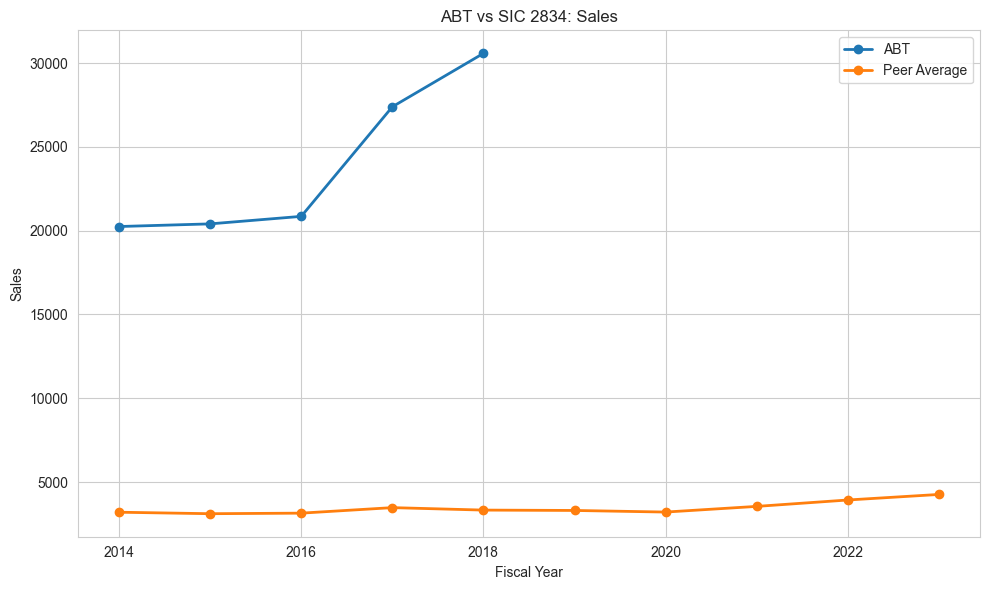

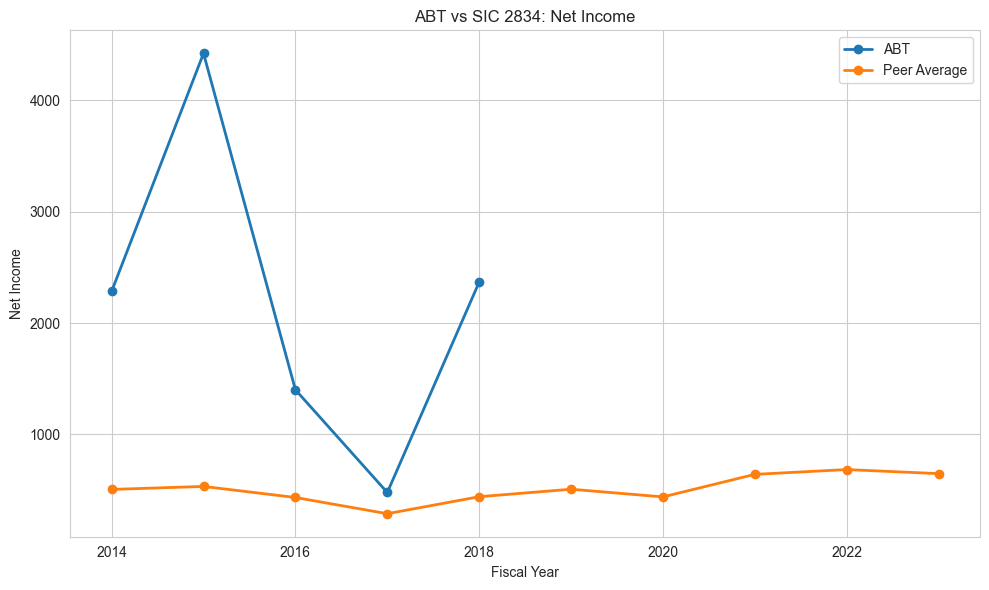

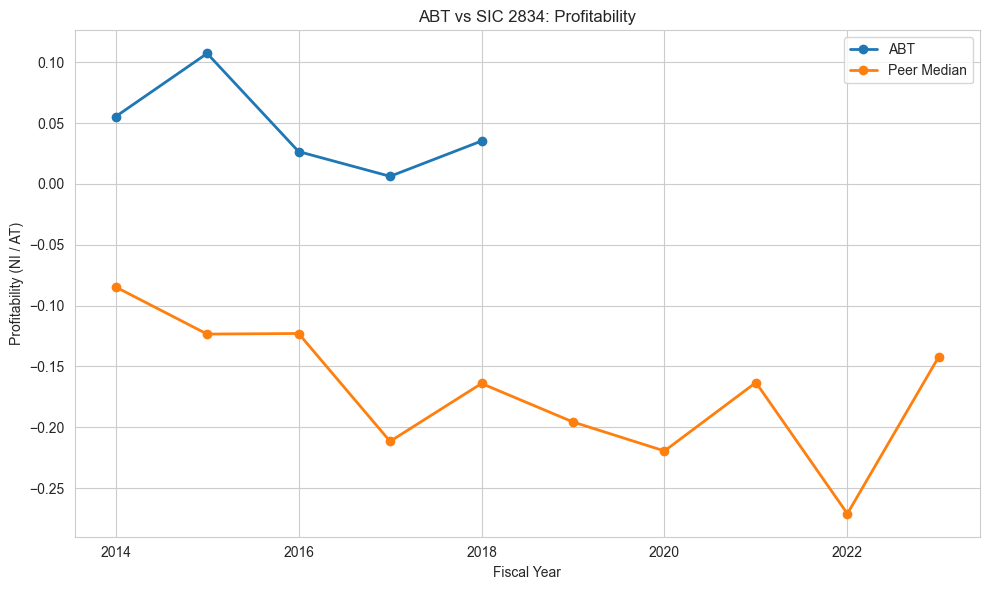

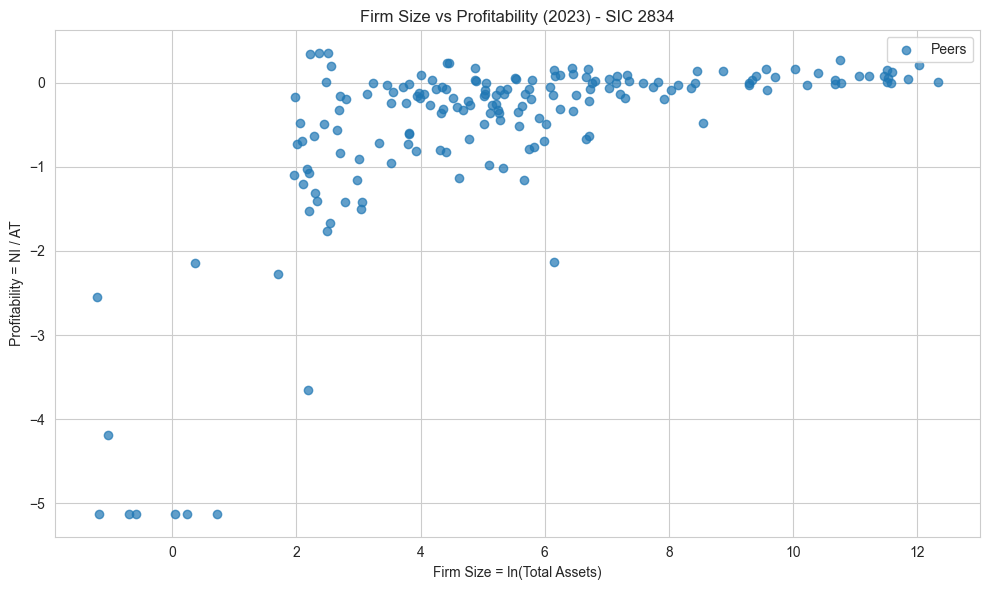


Saved: ABT_vs_SIC3845_improved_comparison.csv


In [240]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Copy and clean data
# =========================
data = df.copy()

data['tic'] = data['tic'].astype(str).str.strip().str.upper()
data['conm'] = data['conm'].astype(str).str.strip()
data['sic'] = data['sic'].astype(str).str.strip()
data['fyear'] = pd.to_numeric(data['fyear'], errors='coerce')

for col in ['sale', 'ni', 'at', 'firm_size', 'profitability']:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

data = data.dropna(subset=['tic', 'fyear'])

# =========================
# 2. Recalculate firm_size and profitability safely
# =========================
# firm size = ln(total assets), only if at > 0
data['firm_size'] = np.where(data['at'] > 0, np.log(data['at']), np.nan)

# profitability = ni / at, only if at > 0
data['profitability'] = np.where(data['at'] > 0, data['ni'] / data['at'], np.nan)

# =========================
# 3. Winsorize profitability to reduce extreme outliers
# =========================
def winsorize_series(s, lower=0.01, upper=0.99):
    lower_val = s.quantile(lower)
    upper_val = s.quantile(upper)
    return s.clip(lower=lower_val, upper=upper_val)

data['profitability_w'] = data.groupby('fyear')['profitability'].transform(
    lambda x: winsorize_series(x.dropna()) if x.notna().sum() > 0 else x
)

# 如果 transform 后有些行没对齐，可以再保险一点：
mask = data['profitability_w'].isna() & data['profitability'].notna()
data.loc[mask, 'profitability_w'] = data.loc[mask, 'profitability']

# =========================
# 4. Find ABT and choose industry
# =========================
abt_rows = data[data['tic'] == 'ABT']
if abt_rows.empty:
    raise ValueError("ABT is not found in your dataframe.")

abt_sic = abt_rows['sic'].dropna().iloc[0]
abt_prefix2 = abt_sic[:2]

same_sic = data[data['sic'] == abt_sic].copy()
broad_industry = data[data['sic'].str.startswith(abt_prefix2, na=False)].copy()

same_sic_peer_count = same_sic[same_sic['tic'] != 'ABT']['tic'].nunique()

if same_sic_peer_count >= 5:
    industry_df = same_sic.copy()
    industry_label = f"SIC {abt_sic}"
else:
    industry_df = broad_industry.copy()
    industry_label = f"{abt_prefix2}xx industry"

abt_df = industry_df[industry_df['tic'] == 'ABT'].copy()
peer_df = industry_df[industry_df['tic'] != 'ABT'].copy()

print("Using peer group:", industry_label)
print("Peer companies excluding ABT:", peer_df['tic'].nunique())

# =========================
# 5. Compute yearly values
# For peers:
# - sale: mean
# - ni: mean
# - firm_size: mean
# - profitability: median (more robust)
# =========================
peer_yearly = (
    peer_df.groupby('fyear')
    .agg(
        sale_peer=('sale', 'mean'),
        ni_peer=('ni', 'mean'),
        firm_size_peer=('firm_size', 'mean'),
        profitability_peer=('profitability_w', 'median')
    )
    .reset_index()
)

abt_yearly = (
    abt_df.groupby('fyear')
    .agg(
        sale_abt=('sale', 'mean'),
        ni_abt=('ni', 'mean'),
        firm_size_abt=('firm_size', 'mean'),
        profitability_abt=('profitability_w', 'mean')
    )
    .reset_index()
)

comparison_df = pd.merge(abt_yearly, peer_yearly, on='fyear', how='outer').sort_values('fyear')

print("\n===== Improved ABT vs Peer Table =====")
print(comparison_df)

# =========================
# 6. Plot style
# =========================
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# =========================
# 7. Plot Sales
# =========================
plt.figure()
plt.plot(comparison_df['fyear'], comparison_df['sale_abt'], marker='o', linewidth=2, label='ABT')
plt.plot(comparison_df['fyear'], comparison_df['sale_peer'], marker='o', linewidth=2, label='Peer Average')
plt.title(f'ABT vs {industry_label}: Sales')
plt.xlabel('Fiscal Year')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 8. Plot Net Income
# =========================
plt.figure()
plt.plot(comparison_df['fyear'], comparison_df['ni_abt'], marker='o', linewidth=2, label='ABT')
plt.plot(comparison_df['fyear'], comparison_df['ni_peer'], marker='o', linewidth=2, label='Peer Average')
plt.title(f'ABT vs {industry_label}: Net Income')
plt.xlabel('Fiscal Year')
plt.ylabel('Net Income')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 9. Plot Profitability
# =========================
plt.figure()
plt.plot(comparison_df['fyear'], comparison_df['profitability_abt'], marker='o', linewidth=2, label='ABT')
plt.plot(comparison_df['fyear'], comparison_df['profitability_peer'], marker='o', linewidth=2, label='Peer Median')
plt.title(f'ABT vs {industry_label}: Profitability')
plt.xlabel('Fiscal Year')
plt.ylabel('Profitability (NI / AT)')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 10. Scatter plot for latest year
# =========================
latest_year = int(industry_df['fyear'].dropna().max())
scatter_df = industry_df[industry_df['fyear'] == latest_year].copy()

plt.figure(figsize=(10, 6))
peer_scatter = scatter_df[scatter_df['tic'] != 'ABT']
abt_scatter = scatter_df[scatter_df['tic'] == 'ABT']

plt.scatter(
    peer_scatter['firm_size'],
    peer_scatter['profitability_w'],
    alpha=0.7,
    label='Peers'
)

if not abt_scatter.empty:
    plt.scatter(
        abt_scatter['firm_size'],
        abt_scatter['profitability_w'],
        color='red',
        s=150,
        marker='*',
        label='ABT'
    )
    for _, row in abt_scatter.iterrows():
        plt.annotate(
            'ABT',
            (row['firm_size'], row['profitability_w']),
            textcoords='offset points',
            xytext=(8, 5),
            ha='left'
        )

plt.title(f'Firm Size vs Profitability ({latest_year}) - {industry_label}')
plt.xlabel('Firm Size = ln(Total Assets)')
plt.ylabel('Profitability = NI / AT')
plt.legend()
plt.tight_layout()
plt.show()

# =========================
# 11. Save results
# =========================
comparison_df.to_csv("ABT_vs_SIC3845_improved_comparison.csv", index=False)
print("\nSaved: ABT_vs_SIC3845_improved_comparison.csv")

## Comparison of the Two Sets of Figures
### The two sets of figures lead to broadly consistent conclusions regarding Abbott Laboratories’ relative position within SIC 2834. In both cases, ABT reports substantially higher sales than its peer firms and generally stronger net income performance over time. These results indicate that Abbott operates at a significantly larger scale and achieves stronger earnings than the typical firm in the industry.
### The main difference between the two sets of figures lies in the measurement of peer profitability. One set compares ABT with the peer median, while the other uses the peer average. This distinction is important because the average is more sensitive to extreme observations, whereas the median provides a more robust measure of the typical peer firm. As a result, peer profitability appears much lower and more volatile in the figures based on the average, suggesting that the industry contains a number of firms with unusually poor profitability.
### Overall, both sets of figures support the conclusion that ABT performs favorably relative to its peers. However, the median-based comparison provides a more stable and representative benchmark, while the average-based comparison better highlights the effect of outliers within the peer group.

## 3.1 Peer Group Selection
### Abbott Laboratories (ABT) is benchmarked against companies operating within SIC 2834 (Pharmaceutical Preparations), which represents a relevant four-digit narrow industry classification. This peer group is well suited for analysis because SIC 2834 contains a sufficiently large and diverse set of comparable firms, allowing for a more precise performance comparison than a broader two-digit SIC industry grouping.
## 3.2 Comparative Scale and Earnings Performance
### Across the full 2014–2023 sample period, ABT shows a clear advantage in operational scale relative to the industry peer average.
### As shown in the sales trend chart, ABT’s total revenue is several times larger than the peer-group average in every fiscal year. ABT’s sales also increase notably after 2016, which further widens its scale advantage relative to other firms in the industry over time.
### A similar pattern is observed for net income. ABT maintains a persistent and substantial lead over the peer average throughout the period. Although ABT’s net income shows some year-to-year volatility, it remains above the industry average benchmark in each year and frequently reaches levels well above typical peer performance. By contrast, peer-group average net income remains relatively low and fairly stable across the sample period.
## 3.3 Profitability and Competitive Standing
### Profitability, measured as Net Income divided by Total Assets (NI/AT), suggests an even clearer difference between ABT and its peers.
### ABT maintains consistently positive and relatively stable profitability across all years in the dataset. In contrast, both peer median and peer average profitability remain negative throughout the sample period, with noticeable volatility and several sharp downturns within the industry group. This indicates that ABT generates stronger and more consistent returns on assets than the typical firm in SIC 2834.
### The firm size versus profitability scatter plot further supports this interpretation. Most smaller industry firms, measured by total asset size, are concentrated at relatively low or negative profitability levels. As firm size increases, industry profitability appears to move closer to break-even. ABT is located at the far right of the distribution, reflecting its very large asset base, and also exhibits positive profitability. This places the firm among the larger and better-performing companies in the sector.
## 3.4 Overall Conclusion
### In summary, the empirical comparison indicates that Abbott Laboratories occupies a particularly strong position within SIC 2834.
### ABT exceeds its peers in terms of operating scale, reports consistently stronger net income, and demonstrates more favorable and stable profitability. While the broader SIC 2834 peer group shows generally weak average and median profitability, ABT maintains positive financial performance throughout the sample period. Overall, the evidence suggests that ABT is both one of the largest firms and one of the stronger financial performers within its pharmaceutical preparations peer group.

## Figure Captions
### Figure 1: ABT vs SIC 2834 Peer Group Sales (2014–2023)
### This line chart compares the annual sales revenue of Abbott Laboratories with the peer-group average for SIC 2834. ABT records substantially higher sales in every year and shows strong revenue growth from 2016 onward, while peer average sales remain comparatively modest and fairly stable over the period.
## Figure 2: ABT vs SIC 2834 Peer Group Net Income (2014–2023)
### This chart presents annual net income for ABT relative to the industry average. ABT’s net income remains consistently above the peer benchmark; despite some fluctuations, its earnings performance is materially stronger than the relatively low and stable average earnings of peer firms.
## Figure 3: ABT vs SIC 2834 Profitability (NI/AT, 2014–2023)
### This figure compares the profitability of ABT and SIC 2834 peers over time. ABT maintains positive and relatively stable profitability throughout the period, while peer median and peer average profitability remain negative and more volatile, highlighting ABT’s stronger operating performance.
## Figure 4: Firm Size vs Profitability Distribution, SIC 2834 (2023)
### This scatter plot shows SIC 2834 firms by logged total asset size and profitability. Smaller firms are generally associated with weaker or negative profitability, while ABT appears at the high end of firm size with positive profitability, indicating a strong position among large firms in the industry.